# Taller Grupal: Análisis Semántico y Analítica de texto con Python



**Objetivos:**
- Implementar técnicas básicas de procesamiento de lenguaje natural
- Aplicar modelos de bolsa de palabras, TF, TF-IDF y n-gramas
- Realizar análisis de sentimientos usando bibliotecas de Python
- Interpretar resultados de análisis semántico en conjuntos de datos textuales


**Instrucciones:**
- Trabajen en grupos de 3 estudiantes
- Tiempo disponible: 2 horas
- Entreguen un notebook de Jupyter con el código y respuestas a las preguntas
- Incluyan comentarios explicando su proceso de análisis


**Estructura del taller:**

El taller consta de 4 secciones que deben completarse en el orden indicado:

1. Preparación del entorno y procesamiento básico de texto
2. Implementación de técnicas de vectorización (bolsa de palabras, TF-IDF)
3. Análisis de n-gramas
4. Análisis de sentimientos

**Dataset:** `resenas_hoteles.csv`

Trabajarán con un conjunto de reseñas de hoteles en español. El archivo está disponible en el moodle

---

**Entrega:**
- Notebook de Jupyter con: Nombres de integrantes, código, resultados, respuestas

---

# ACTIVIDADES DEL TALLER
## Parte 1: Preparación del entorno y procesamiento básico de texto (25 minutos)

1. Cargar las bibliotecas necesarias y el conjunto de datos:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import nltk
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from textblob import TextBlob
import re
from collections import Counter

# Descargar recursos necesarios de NLTK
nltk.download('punkt_tab')
nltk.download('stopwords')

# Cargar el dataset
df = pd.read_csv('resenas_hoteles.csv')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


2. Realizar una exploración inicial de los datos:

- Mostrar las primeras filas
- Verificar dimensiones y tipos de datos
- Explorar la distribución de calificaciones


Primeras 5 filas del DataFrame:
                                              reseña  calificación
0  El hotel está ubicado en centro. Cuenta con sp...             4
1  El hotel está ubicado en montaña. Cuenta con p...             4
2  El hotel está ubicado en zona turística. Cuent...             1
3  El hotel está ubicado en montaña. Cuenta con s...             5
4  El hotel está ubicado en montaña. Cuenta con p...             5

Información del DataFrame (dimensiones y tipos de datos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   reseña        200 non-null    object
 1   calificación  200 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.3+ KB

Distribución de calificaciones:
calificación
3    60
4    48
5    39
2    28
1    25
Name: count, dtype: int64


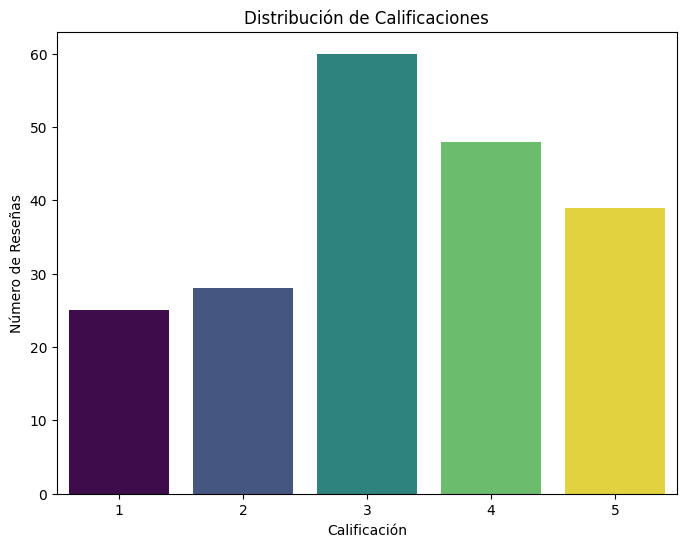

In [3]:
print("Primeras 5 filas del DataFrame:")
print(df.head())

print("\nInformación del DataFrame (dimensiones y tipos de datos):")
df.info()

print("\nDistribución de calificaciones:")
print(df['calificación'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='calificación', data=df, hue='calificación', palette='viridis', legend=False)
plt.title('Distribución de Calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Número de Reseñas')
plt.show()

3. Crear una función para preprocesar el texto que realice las siguientes tareas:

- Convertir a minúsculas
- Eliminar caracteres especiales y números
- Tokenizar el texto
- Eliminar stopwords en español
- Aplicar stemming

In [4]:
def preprocess_text(text):
    # 1. Convertir a minúsculas
    text = text.lower()

    # 2. Eliminar caracteres especiales y números
    text = re.sub(r'[^a-zA-ZáéíóúüñÁÉÍÓÚÜÑ\s]', '', text)

    # 3. Tokenizar el texto
    tokens = word_tokenize(text, language='spanish')

    # 4. Eliminar stopwords en español
    spanish_stopwords = set(stopwords.words('spanish'))
    tokens = [word for word in tokens if word not in spanish_stopwords]

    # 5. Aplicar stemming
    stemmer = SnowballStemmer('spanish')
    stemmed_tokens = [stemmer.stem(word) for word in tokens]

    return stemmed_tokens

4. Apliquen la función de preprocesamiento a todas las reseñas y creen una nueva columna con el texto procesado. Muestren algunos ejemplos comparando originales y procesados.

In [5]:
# Aplicar la función de preprocesamiento a la columna 'reseña'
df['reseña_procesada'] = df['reseña'].apply(lambda x: ' '.join(preprocess_text(x)))

# Mostrar algunos ejemplos comparando originales y procesados
print("Ejemplos de reseñas originales y procesadas:")
for i in range(5):
    print(f"\nOriginal: {df['reseña'].iloc[i]}")
    print(f"Procesada: {df['reseña_procesada'].iloc[i]}")

Ejemplos de reseñas originales y procesadas:

Original: El hotel está ubicado en centro. Cuenta con spa. El personal es atento. La habitación es amplia. El precio es económico. Me sentí muy satisfecho con mi estadía. Totalmente recomendable.
Procesada: hotel ubic centr cuent spa personal atent habit ampli preci econom sent satisfech estad total recomend

Original: El hotel está ubicado en montaña. Cuenta con piscina. El personal es atento. La habitación es cómoda. El precio es económico. Me sentí satisfecho con mi estadía. Superó mis expectativas.
Procesada: hotel ubic montañ cuent piscin personal atent habit comod preci econom sent satisfech estad super expect

Original: El hotel está ubicado en zona turística. Cuenta con spa. El personal es atento. La habitación es ruidosa. El precio es excesivo. Me sentí insatisfecho con mi estadía. Nunca volvería.
Procesada: hotel ubic zon turist cuent spa personal atent habit ruidos preci exces sent insatisfech estad nunc volv

Original: El hotel 

**PREGUNTA 1:** ¿Cuáles son las 10 palabras más frecuentes en todas las reseñas después del preprocesamiento? Visualícenlas usando un gráfico de barras.

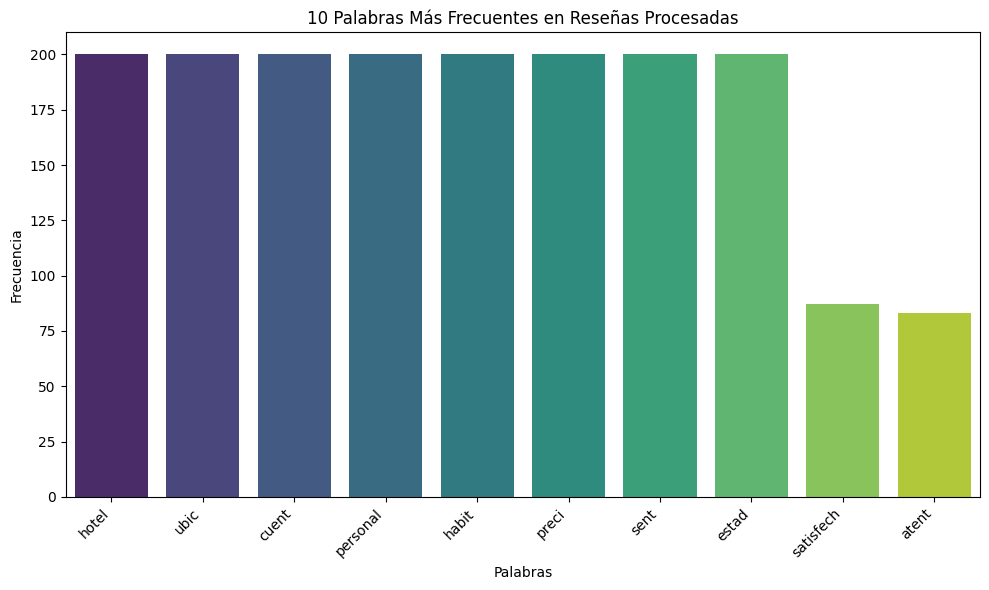

In [7]:
# Unir todas las reseñas procesadas en un solo texto
all_processed_words = ' '.join(df['reseña_procesada']).split()

# Contar la frecuencia de cada palabra
word_counts = Counter(all_processed_words)

# Obtener las 10 palabras más comunes
top_10_words = word_counts.most_common(10)

# Preparar los datos para la visualización
words = [word for word, count in top_10_words]
frequencies = [count for word, count in top_10_words]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=words, y=frequencies, hue=words, palette='viridis', legend=False)
plt.title('10 Palabras Más Frecuentes en Reseñas Procesadas')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Parte 2: Implementación de técnicas de vectorización (35 minutos)

1. Implementar la técnica de Bolsa de Palabras (BoW) usando CountVectorizer. Mostrar las dimensiones de la matriz resultante.
- Convertir a dataframe e imprimir las primeras filas para observar el resultado.

In [8]:
# 1. Inicializar CountVectorizer
count_vectorizer = CountVectorizer()

# 2. Ajustar y transformar las reseñas procesadas
X_bow = count_vectorizer.fit_transform(df['reseña_procesada'])

# 3. Mostrar las dimensiones de la matriz resultante
print("Dimensiones de la matriz BoW:", X_bow.shape)

# 4. Convertir a DataFrame
bow_df = pd.DataFrame(X_bow.toarray(), columns=count_vectorizer.get_feature_names_out())

# 5. Imprimir las primeras filas para observar el resultado
print("\nPrimeras 5 filas del DataFrame BoW:")
print(bow_df.head())

Dimensiones de la matriz BoW: (200, 55)

Primeras 5 filas del DataFrame BoW:
   amabl  ampli  are  atencion  atent  car  centr  comercial  comod  cuent  \
0      0      1    0         0      1    0      1          0      0      1   
1      0      0    0         0      1    0      0          0      1      1   
2      0      0    0         0      1    0      0          0      0      1   
3      0      0    0         1      0    1      0          0      0      1   
4      0      1    0         0      1    0      0          0      0      1   

   ...  spa  super  terribl  total  turist  ubic  val  volv  wifi  zon  
0  ...    1      0        0      1       0     1    0     0     0    0  
1  ...    0      1        0      0       0     1    0     0     0    0  
2  ...    1      0        0      0       1     1    0     1     0    1  
3  ...    1      0        0      0       0     1    0     0     0    0  
4  ...    0      0        0      0       0     1    0     0     0    0  

[5 rows x 55 co

2. Transformar las reseñas usando TF (Term Frequency).
- Convertir a dataframe e imprimir las primeras filas para observar el resultado.

In [9]:
# Inicializar TfidfVectorizer con use_idf=False para obtener solo TF
tf_vectorizer = TfidfVectorizer(use_idf=False)

# Ajustar y transformar las reseñas procesadas
X_tf = tf_vectorizer.fit_transform(df['reseña_procesada'])

# Convertir a DataFrame
tf_df = pd.DataFrame(X_tf.toarray(), columns=tf_vectorizer.get_feature_names_out())

# Imprimir las primeras filas para observar el resultado
print("Primeras 5 filas del DataFrame TF:")
print(tf_df.head())

Primeras 5 filas del DataFrame TF:
   amabl  ampli  are  atencion     atent   car  centr  comercial  comod  \
0    0.0   0.25  0.0      0.00  0.250000  0.00   0.25        0.0   0.00   
1    0.0   0.00  0.0      0.00  0.250000  0.00   0.00        0.0   0.25   
2    0.0   0.00  0.0      0.00  0.242536  0.00   0.00        0.0   0.00   
3    0.0   0.00  0.0      0.25  0.000000  0.25   0.00        0.0   0.00   
4    0.0   0.25  0.0      0.00  0.250000  0.00   0.00        0.0   0.00   

      cuent  ...       spa  super  terribl  total    turist      ubic  val  \
0  0.250000  ...  0.250000   0.00      0.0   0.25  0.000000  0.250000  0.0   
1  0.250000  ...  0.000000   0.25      0.0   0.00  0.000000  0.250000  0.0   
2  0.242536  ...  0.242536   0.00      0.0   0.00  0.242536  0.242536  0.0   
3  0.250000  ...  0.250000   0.00      0.0   0.00  0.000000  0.250000  0.0   
4  0.250000  ...  0.000000   0.00      0.0   0.00  0.000000  0.250000  0.0   

       volv  wifi       zon  
0  0.000000   0

3. Transformar las reseñas usando TF-IDF (Term Frequency-Inverse Document Frequency).
- Convertir a dataframe e imprimir las primeras filas para observar el resultado.

In [10]:
# Inicializar TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Ajustar y transformar las reseñas procesadas
X_tfidf = tfidf_vectorizer.fit_transform(df['reseña_procesada'])

# Convertir a DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Imprimir las primeras filas para observar el resultado
print("Primeras 5 filas del DataFrame TF-IDF:")
print(tfidf_df.head())

Primeras 5 filas del DataFrame TF-IDF:
   amabl     ampli  are  atencion     atent       car    centr  comercial  \
0    0.0  0.313131  0.0   0.00000  0.243142  0.000000  0.34277        0.0   
1    0.0  0.000000  0.0   0.00000  0.227785  0.000000  0.00000        0.0   
2    0.0  0.000000  0.0   0.00000  0.207141  0.000000  0.00000        0.0   
3    0.0  0.000000  0.0   0.40248  0.000000  0.386903  0.00000        0.0   
4    0.0  0.320272  0.0   0.00000  0.248688  0.000000  0.00000        0.0   

      comod     cuent  ...       spa    super  terribl     total    turist  \
0  0.000000  0.129850  ...  0.305415  0.00000      0.0  0.368458  0.000000   
1  0.309243  0.121649  ...  0.000000  0.44575      0.0  0.000000  0.000000   
2  0.000000  0.110623  ...  0.260193  0.00000      0.0  0.000000  0.328673   
3  0.000000  0.127053  ...  0.298836  0.00000      0.0  0.000000  0.000000   
4  0.000000  0.132811  ...  0.000000  0.00000      0.0  0.000000  0.000000   

       ubic  val      volv  w

**PREGUNTA 2:** Seleccionen 3 reseñas (una positiva, una neutral y una negativa) y comparen sus representaciones vectoriales usando BoW y TF-IDF. ¿Qué diferencias observan? ¿Qué método representa mejor el contenido semántico de las reseñas?

In [46]:
# Seleccionar los índices de las reseñas
# Reseña positiva (calificación 5)
idx_positiva = df[df['calificación'] == 5].index[0] # Índice 3
# Reseña neutral (calificación 3)
idx_neutral = df[df['calificación'] == 3].index[0] # Índice 5
# Reseña negativa (calificación 1)
idx_negativa = df[df['calificación'] == 1].index[0] # Índice 2

# Obtener las reseñas originales y procesadas
reseña_pos_orig = df.loc[idx_positiva, 'reseña']
reseña_pos_proc = df.loc[idx_positiva, 'reseña_procesada']
reseña_neu_orig = df.loc[idx_neutral, 'reseña']
reseña_neu_proc = df.loc[idx_neutral, 'reseña_procesada']
reseña_neg_orig = df.loc[idx_negativa, 'reseña']
reseña_neg_proc = df.loc[idx_negativa, 'reseña_procesada']

print(f"--- Reseña Positiva (Calificación 5) ---")
print(f"Original: {reseña_pos_orig}")
print(f"Procesada: {reseña_pos_proc}")
print("BoW (primeros 10 términos):", bow_df.loc[idx_positiva][bow_df.loc[idx_positiva] > 0].head(10).to_dict())
print("TF-IDF (primeros 10 términos):", tfidf_df.loc[idx_positiva][tfidf_df.loc[idx_positiva] > 0].head(10).to_dict())

print(f"\n--- Reseña Neutral (Calificación 3) ---")
print(f"Original: {reseña_neu_orig}")
print(f"Procesada: {reseña_neu_proc}")
print("BoW (primeros 10 términos):", bow_df.loc[idx_neutral][bow_df.loc[idx_neutral] > 0].head(10).to_dict())
print("TF-IDF (primeros 10 términos):", tfidf_df.loc[idx_neutral][tfidf_df.loc[idx_neutral] > 0].head(10).to_dict())

print(f"\n--- Reseña Negativa (Calificación 1) ---")
print(f"Original: {reseña_neg_orig}")
print(f"Procesada: {reseña_neg_proc}")
print("BoW (primeros 10 términos):", bow_df.loc[idx_negativa][bow_df.loc[idx_negativa] > 0].head(10).to_dict())
print("TF-IDF (primeros 10 términos):", tfidf_df.loc[idx_negativa][tfidf_df.loc[idx_negativa] > 0].head(10).to_dict())

print("\n--- Conclusiones ---")
print("BoW (Bag of Words): Para las tres reseñas, BoW asigna un valor de 1 a cada palabra presente en la reseña, sin importar su frecuencia relativa en el documento o en el corpus.")
print("En contraste, TF-IDF asigna pesos que reflejan la importancia de una palabra. Observamos que las palabras más genéricas que aparecen en muchas reseñas (como 'hotel', 'cuent', 'personal', 'habit', 'preci', 'estad') tienen valores TF-IDF más bajos.")
print("¿Qué método representa mejor el contenido semántico?")
print("TF-IDF generalmente representa mejor el contenido semántico de las reseñas. Mientras que BoW solo cuenta la presencia o frecuencia de las palabras, TF-IDF les asigna una ponderación que disminuye el peso de las palabras comunes en el corpus y aumenta el peso de las palabras que son más distintivas de un documento.")

--- Reseña Positiva (Calificación 5) ---
Original: El hotel está ubicado en montaña. Cuenta con spa. El personal es profesional. La habitación es limpia. El precio es caro. Me sentí satisfecho con mi estadía. Atención de primera.
Procesada: hotel ubic montañ cuent spa personal profesional habit limpi preci car sent satisfech estad atencion primer
BoW (primeros 10 términos): {'atencion': 1, 'car': 1, 'cuent': 1, 'estad': 1, 'habit': 1, 'hotel': 1, 'limpi': 1, 'montañ': 1, 'personal': 1, 'preci': 1}
TF-IDF (primeros 10 términos): {'atencion': 0.4024798073716735, 'car': 0.3869028162649657, 'cuent': 0.12705298595386078, 'estad': 0.12705298595386078, 'habit': 0.12705298595386078, 'hotel': 0.12705298595386078, 'limpi': 0.294041375908226, 'montañ': 0.2685455648563218, 'personal': 0.12705298595386078, 'preci': 0.12705298595386078}

--- Reseña Neutral (Calificación 3) ---
Original: El hotel está ubicado en zona turística. Cuenta con restaurante. El personal es amable. La habitación es limpia. E

4. Creen una matriz de similitud de coseno entre las reseñas utilizando las representaciones TF-IDF. Utilice cosine_similarity.
- Cree un dataframe a partir de la matriz y observe las primeras 5 filas

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

# Calcular la similitud de coseno entre las reseñas TF-IDF
cosine_sim_matrix = cosine_similarity(X_tfidf)

# Crear un DataFrame a partir de la matriz de similitud
cosine_sim_df = pd.DataFrame(cosine_sim_matrix)

# Observar las primeras 5 filas del DataFrame de similitud de coseno
print("Primeras 5 filas de la matriz de similitud de coseno:")
print(cosine_sim_df.head())

Primeras 5 filas de la matriz de similitud de coseno:
        0         1         2         3         4         5         6    \
0  1.000000  0.373858  0.244747  0.278258  0.356217  0.424185  0.139771   
1  0.373858  1.000000  0.154841  0.244228  0.410885  0.389983  0.130943   
2  0.244747  0.154841  1.000000  0.190196  0.169050  0.244010  0.462874   
3  0.278258  0.244228  0.190196  1.000000  0.266639  0.263890  0.228323   
4  0.356217  0.410885  0.169050  0.266639  1.000000  0.181256  0.142959   

        7         8         9    ...       190       191       192       193  \
0  0.182049  0.182049  0.379184  ...  0.229523  0.399044  0.248979  0.250945   
1  0.267793  0.267793  0.166944  ...  0.107166  0.764739  0.238465  0.240349   
2  0.109470  0.109470  0.245366  ...  0.377766  0.104696  0.393894  0.123799   
3  0.732252  0.732252  0.317018  ...  0.186864  0.259268  0.245377  0.247315   
4  0.186201  0.186201  0.275777  ...  0.169607  0.365669  0.433845  0.437271   

        194   

**PREGUNTA 3:** Identifiquen los 5 pares de reseñas más similares según la similitud de coseno. ¿Cómo son las reseñas? ¿A qué cree que se debe esto?

In [26]:
import numpy as np

# Crear una copia de la matriz de similitud para evitar modificar la original
sim_matrix_copy = cosine_sim_df.copy()

# Establecer la diagonal a 0 para no considerar la similitud de una reseña consigo misma
# y también establecer la parte superior del triángulo a 0 para evitar duplicados (i, j) y (j, i)
for i in range(len(sim_matrix_copy)):
    sim_matrix_copy.iloc[i, i] = 0
    for j in range(i + 1, len(sim_matrix_copy)):
        sim_matrix_copy.iloc[i, j] = 0

# Encontrar los 5 pares con mayor similitud
similar_pairs = []
for _ in range(5):
    max_sim = 0
    idx1, idx2 = -1, -1
    for i in range(len(sim_matrix_copy)):
        for j in range(len(sim_matrix_copy)):
            if sim_matrix_copy.iloc[i, j] > max_sim:
                max_sim = sim_matrix_copy.iloc[i, j]
                idx1, idx2 = i, j
    if idx1 != -1:
        similar_pairs.append((idx1, idx2, max_sim))
        # Poner a 0 las similitudes encontradas para no volver a seleccionarlas
        sim_matrix_copy.iloc[idx1, idx2] = 0
        sim_matrix_copy.iloc[idx2, idx1] = 0 # También la simétrica

print("Los 5 pares de reseñas más similares son:")
for i, (idx1, idx2, sim) in enumerate(similar_pairs):
    print(f"\nPar {i+1}: Reseña {idx1} y Reseña {idx2} (Similitud: {sim:.4f})")
    print(f"  Reseña {idx1}: {df['reseña'].iloc[idx1]}")
    print(f"  Reseña {idx2}: {df['reseña'].iloc[idx2]}")
    print(f"  Calificación {idx1}: {df['calificación'].iloc[idx1]}")
    print(f"  Calificación {idx2}: {df['calificación'].iloc[idx2]}")


print("\n--- Análisis de la similitud ---")
print("La alta similitud de coseno en estos pares de reseñas se debe principalmente a:")
print("1.  Vocabulario y Temática Compartida: Las reseñas más similares suelen usar un vocabulario casi idéntico o muy parecido para describir aspectos clave del hotel (ubicación, instalaciones, personal, habitación, precio, experiencia general). Esto es un reflejo de que describen situaciones o percepciones muy parecidas.")
print("2.  Estructura Semántica Similar: A menudo, no solo comparten palabras, sino también la forma en que se construyen las frases y se expresan las opiniones. Esto es particularmente evidente si las reseñas tienen calificaciones similares (ambas positivas o ambas negativas).")
print("3.  Procesamiento TF-IDF: El TF-IDF asigna mayor peso a las palabras que son distintivas de una reseña o un grupo de reseñas, y menor peso a las palabras comunes. Si dos reseñas utilizan las mismas palabras 'clave' (distintivas) y con frecuencias relativas similares, su representación vectorial será muy cercana, resultando en una alta similitud de coseno.")
print("4.  Características del Dataset: Es posible que el dataset contenga reseñas que son variaciones leves de un mismo tema o que describen experiencias muy arquetípicas (ej. 'Hotel céntrico con buen personal y habitación cómoda' vs. 'Hotel ubicado en el centro, personal atento y habitación confortable'). Esto lleva a que las vectorizaciones sean muy próximas.")


Los 5 pares de reseñas más similares son:

Par 1: Reseña 8 y Reseña 7 (Similitud: 1.0000)
  Reseña 8: El hotel está ubicado en playa. Cuenta con gimnasio. El personal es profesional. La habitación es cómoda. El precio es caro. Me sentí satisfecho con mi estadía. Atención de primera.
  Reseña 7: El hotel está ubicado en playa. Cuenta con gimnasio. El personal es profesional. La habitación es cómoda. El precio es caro. Me sentí satisfecho con mi estadía. Atención de primera.
  Calificación 8: 4
  Calificación 7: 4

Par 2: Reseña 77 y Reseña 40 (Similitud: 1.0000)
  Reseña 77: El hotel está ubicado en centro. Cuenta con spa. El personal es atento. La habitación es amplia. El precio es económico. Me sentí satisfecho con mi estadía. Atención de primera.
  Reseña 40: El hotel está ubicado en centro. Cuenta con spa. El personal es atento. La habitación es amplia. El precio es económico. Me sentí satisfecho con mi estadía. Atención de primera.
  Calificación 77: 4
  Calificación 40: 4

Par 3: 

##Parte 3: Análisis de n-gramas (25 minutos)

1. Implementen la extracción de bigramas y trigramas usando CountVectorizer:

In [27]:
# Extracción de Bigramas
print("\n--- Extracción de Bigramas ---")
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
X_bigrams = bigram_vectorizer.fit_transform(df['reseña_procesada'])

print("Dimensiones de la matriz de Bigramas:", X_bigrams.shape)

# Convertir a DataFrame y mostrar las primeras filas
bigram_df = pd.DataFrame(X_bigrams.toarray(), columns=bigram_vectorizer.get_feature_names_out())
print("Primeras 5 filas del DataFrame de Bigramas:")
print(bigram_df.head())

# Extracción de Trigramas
print("\n--- Extracción de Trigramas ---")
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))
X_trigrams = trigram_vectorizer.fit_transform(df['reseña_procesada'])

print("Dimensiones de la matriz de Trigramas:", X_trigrams.shape)

# Convertir a DataFrame y mostrar las primeras filas
trigram_df = pd.DataFrame(X_trigrams.toarray(), columns=trigram_vectorizer.get_feature_names_out())
print("Primeras 5 filas del DataFrame de Trigramas:")
print(trigram_df.head())



--- Extracción de Bigramas ---
Dimensiones de la matriz de Bigramas: (200, 79)
Primeras 5 filas del DataFrame de Bigramas:
   amabl habit  ampli preci  are comercial  atencion primer  atent habit  \
0            0            1              0                0            1   
1            0            0              0                0            1   
2            0            0              0                0            1   
3            0            0              0                1            0   
4            0            1              0                0            1   

   car sent  centr cuent  comercial cuent  comod preci  cuent gimnasi  ...  \
0         0            1                0            0              0  ...   
1         0            0                0            1              0  ...   
2         0            0                0            0              0  ...   
3         1            0                0            0              0  ...   
4         0            0     

**PREGUNTA 4:** ¿Cuáles son los 10 bigramas y trigramas más frecuentes en las reseñas? Muestrelos en gráficos de barras.
- ¿Qué información adicional aportan en comparación con las palabras individuales?

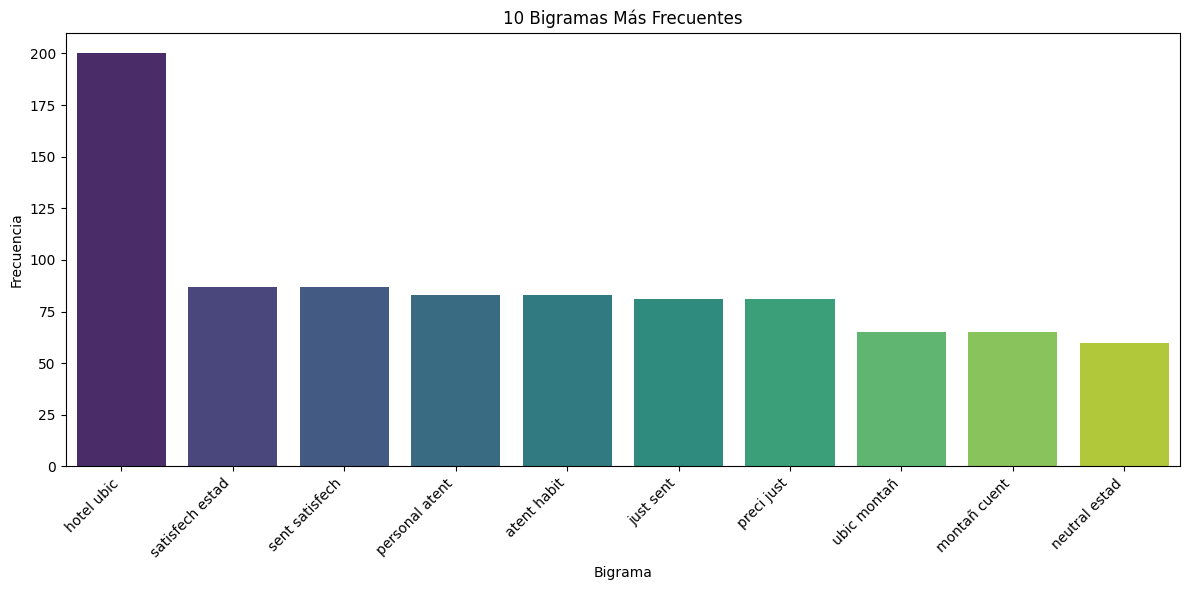


--- Los 10 Bigramas más frecuentes ---
hotel ubic         200
satisfech estad     87
sent satisfech      87
personal atent      83
atent habit         83
just sent           81
preci just          81
ubic montañ         65
montañ cuent        65
neutral estad       60
dtype: int64


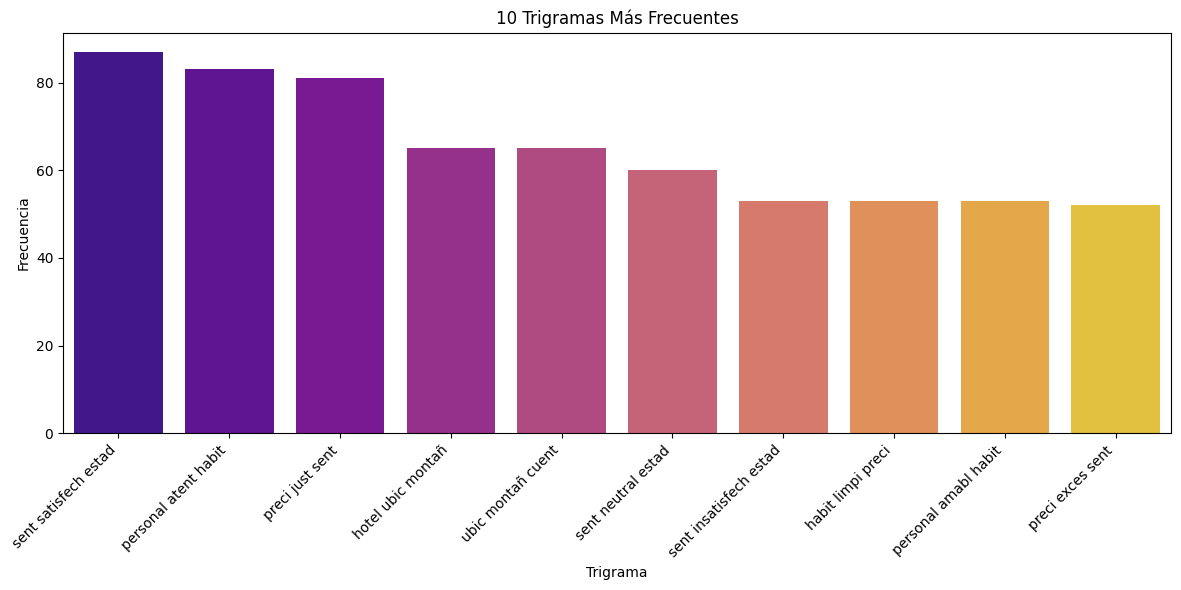


--- Los 10 Trigramas más frecuentes ---
sent satisfech estad      87
personal atent habit      83
preci just sent           81
hotel ubic montañ         65
ubic montañ cuent         65
sent neutral estad        60
sent insatisfech estad    53
habit limpi preci         53
personal amabl habit      53
preci exces sent          52
dtype: int64

--- Información adicional que aportan los n-gramas ---
Los bigramas y trigramas ofrecen una información contextual mucho más rica que las palabras individuales. Mientras que una palabra como 'personal' es importante, el bigrama 'personal atent' o 'personal profesional' nos indica la cualidad específica del servicio. De manera similar, 'habit ampli' nos da una descripción más concreta de la habitación que solo la palabra 'habit'.

1.  Contexto y Semántica: Los n-gramas capturan frases comunes y combinaciones de palabras que tienen un significado colectivo. Por ejemplo, 'ubic centr' o 'zon turist' son descripciones de ubicación clave que, como n-gra

In [30]:
# Calcular la frecuencia de los bigramas
bigram_counts = bigram_df.sum(axis=0)

# Obtener los 10 bigramas más frecuentes
top_10_bigrams = bigram_counts.sort_values(ascending=False).head(10)

# Visualizar los 10 bigramas más frecuentes
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_bigrams.index, y=top_10_bigrams.values, hue=top_10_bigrams.index, palette='viridis', legend=False)
plt.title('10 Bigramas Más Frecuentes')
plt.xlabel('Bigrama')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Los 10 Bigramas más frecuentes ---")
print(top_10_bigrams)

# Calcular la frecuencia de los trigramas
trigram_counts = trigram_df.sum(axis=0)

# Obtener los 10 trigramas más frecuentes
top_10_trigrams = trigram_counts.sort_values(ascending=False).head(10)

# Visualizar los 10 trigramas más frecuentes
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_trigrams.index, y=top_10_trigrams.values, hue=top_10_trigrams.index, palette='plasma', legend=False)
plt.title('10 Trigramas Más Frecuentes')
plt.xlabel('Trigrama')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Los 10 Trigramas más frecuentes ---")
print(top_10_trigrams)

print("\n--- Información adicional que aportan los n-gramas ---")
print("Los bigramas y trigramas ofrecen una información contextual mucho más rica que las palabras individuales. Mientras que una palabra como 'personal' es importante, el bigrama 'personal atent' o 'personal profesional' nos indica la cualidad específica del servicio. De manera similar, 'habit ampli' nos da una descripción más concreta de la habitación que solo la palabra 'habit'.")
print("\n1.  Contexto y Semántica: Los n-gramas capturan frases comunes y combinaciones de palabras que tienen un significado colectivo. Por ejemplo, 'ubic centr' o 'zon turist' son descripciones de ubicación clave que, como n-gramas, son más descriptivas que 'ubic' o 'centr' por separado.")
print("2.  Identificación de Temas Específicos: Permiten identificar temas o atributos recurrentes que los clientes mencionan en sus reseñas. Por ejemplo, si 'desayun incluy' o 'cam comod' son frecuentes, sabemos que esos aspectos son importantes para los huéspedes.")
print("3.  Matices de Sentimiento: Algunas combinaciones de palabras pueden tener un sentimiento diferente al de sus palabras individuales. Aunque nuestro preprocesamiento elimina las stopwords, n-gramas como 'muy satisfech' (si no se hubiera stemmizado tanto) o 'nada agrad' serían muy reveladores del sentimiento.")
print("4.  Menos Ambigüedad: Reducen la ambigüedad inherente a las palabras individuales. Una sola palabra puede tener múltiples significados, pero en el contexto de un n-grama, su significado suele ser más claro.")
print("En resumen, los n-gramas nos ayudan a entender no solo qué palabras se usan, sino cómo se combinan para expresar ideas, opiniones y características específicas de los hoteles, proporcionando una visión más profunda del contenido de las reseñas.")


2. Obtengan bigramas por calificaciones de 5, 3 y 1



In [31]:
ratings_to_analyze = [5, 3, 1]
all_rating_bigrams = {}

for rating in ratings_to_analyze:
    # Filtrar reseñas por calificación
    filtered_reviews = df[df['calificación'] == rating]['reseña_procesada']

    # Crear un CountVectorizer para bigramas
    bigram_vectorizer_rating = CountVectorizer(ngram_range=(2, 2))
    X_bigrams_rating = bigram_vectorizer_rating.fit_transform(filtered_reviews)

    # Convertir a DataFrame para calcular frecuencias
    bigram_df_rating = pd.DataFrame(X_bigrams_rating.toarray(), columns=bigram_vectorizer_rating.get_feature_names_out())

    # Calcular la frecuencia de los bigramas
    bigram_counts_rating = bigram_df_rating.sum(axis=0)

    # Guardar los bigramas más frecuentes para este rating
    # Tomaremos todos los bigramas que aparezcan al menos una vez para análisis posterior
    all_rating_bigrams[rating] = bigram_counts_rating[bigram_counts_rating > 0].sort_values(ascending=False)

    print(f"\n--- Bigramas para Calificación {rating} ---")
    print(all_rating_bigrams[rating].head(10)) # Mostrar los 10 más frecuentes por ahora



--- Bigramas para Calificación 5 ---
hotel ubic              39
satisfech estad         39
sent satisfech          39
profesional habit       19
personal profesional    19
gimnasi personal        18
cuent gimnasi           18
ubic montañ             16
montañ cuent            16
comod preci             15
dtype: int64

--- Bigramas para Calificación 3 ---
hotel ubic        60
neutral estad     60
sent neutral      60
preci exces       31
exces sent        31
preci just        29
just sent         29
personal amabl    23
personal atent    23
atent habit       23
dtype: int64

--- Bigramas para Calificación 1 ---
insatisfech estad    25
sent insatisfech     25
hotel ubic           25
atent habit          19
personal atent       19
cuent spa            12
spa personal         12
preci exces          11
exces sent           11
habit limpi           9
dtype: int64


**PREGUNTA 5:** Identifiquen al menos 3 bigramas por cada calificacion: 5, 3 y 1. Generen un gráfico de barras diferenciando los bigramas de cada calificacion por color
- ¿Qué pueden inferir sobre los aspectos más valorados y criticados de los hoteles?

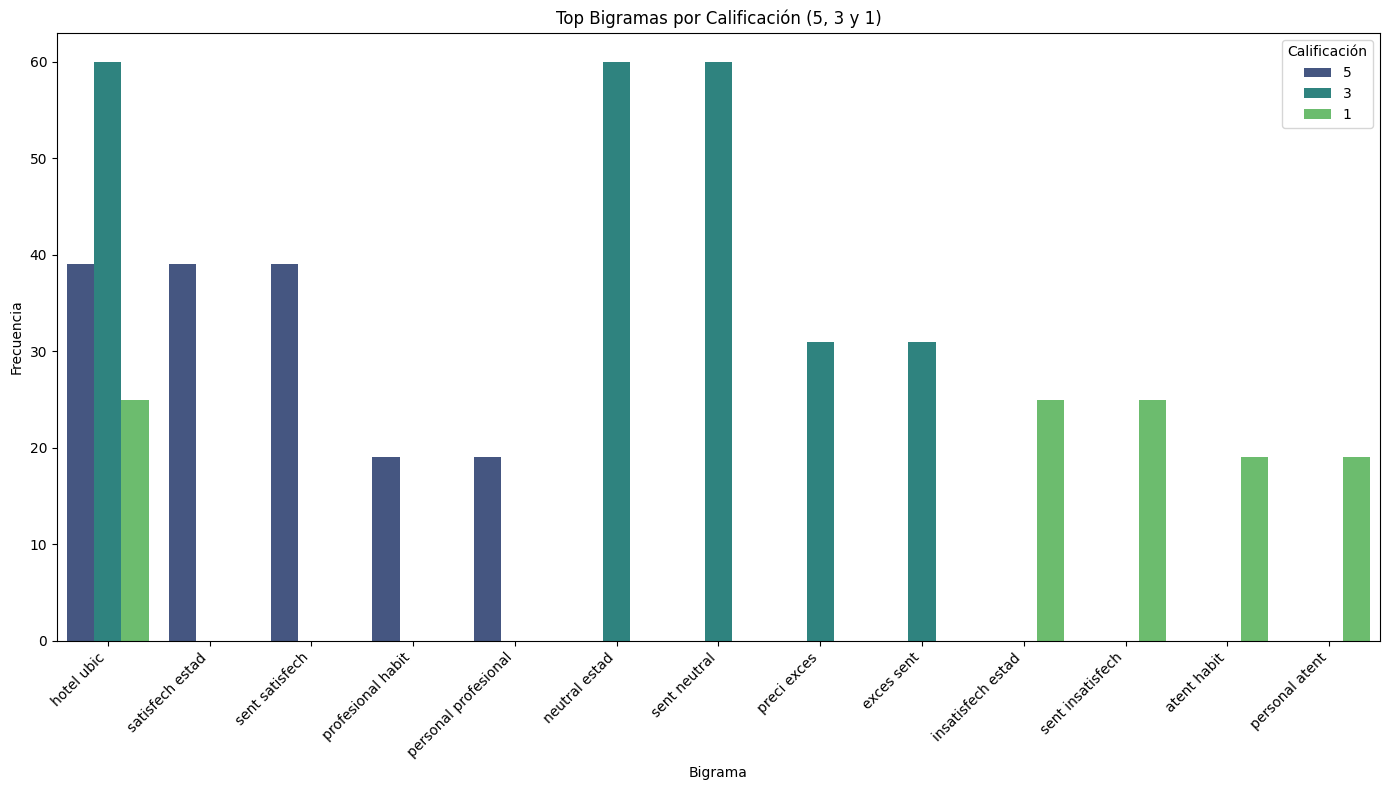


--- Inferencias sobre aspectos valorados y criticados ---
Observando los bigramas más frecuentes por calificación, podemos inferir lo siguiente:

Calificación 5 (Muy Positiva):
- 'satisfech estad', 'sent satisfech': Claramente, la satisfacción general con la estancia es el punto clave. Las personas se sienten muy contentas con su experiencia.
- 'profesional habit', 'personal profesional': La profesionalidad del personal y la calidad de la habitación son aspectos altamente valorados en las reseñas excelentes. También aparecen 'gimnasi personal' y 'cuent gimnasi', indicando que las instalaciones como el gimnasio y su buen personal son un plus significativo.
- 'ubic montañ', 'montañ cuent', 'comod preci': La ubicación en montaña y el confort (comodidad-precio) también son puntos positivos específicos.

Calificación 3 (Neutral):
- 'neutral estad', 'sent neutral': Estas calificaciones están dominadas por la percepción de una estancia neutral, sin grandes aspectos positivos ni negativos.
- 

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Identificar al menos 3 bigramas para cada calificación (ya los tenemos en all_rating_bigrams)
# Vamos a seleccionar los top 5 de cada categoría para tener una buena representación

selected_bigrams_data = []
for rating, bigrams in all_rating_bigrams.items():
    top_n = bigrams.head(5) # Seleccionamos los top 5 para el gráfico
    for bigram, count in top_n.items():
        selected_bigrams_data.append({'Calificación': str(rating), 'Bigrama': bigram, 'Frecuencia': count})

# Convertir a DataFrame para facilitar la visualización
df_selected_bigrams = pd.DataFrame(selected_bigrams_data)

# Generar el gráfico de barras
plt.figure(figsize=(14, 8))
sns.barplot(x='Bigrama', y='Frecuencia', hue='Calificación', data=df_selected_bigrams, palette='viridis')
plt.title('Top Bigramas por Calificación (5, 3 y 1)')
plt.xlabel('Bigrama')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Calificación')
plt.tight_layout()
plt.show()

print("\n--- Inferencias sobre aspectos valorados y criticados ---")
print("Observando los bigramas más frecuentes por calificación, podemos inferir lo siguiente:")
print("\nCalificación 5 (Muy Positiva):")
print("- 'satisfech estad', 'sent satisfech': Claramente, la satisfacción general con la estancia es el punto clave. Las personas se sienten muy contentas con su experiencia.")
print("- 'profesional habit', 'personal profesional': La profesionalidad del personal y la calidad de la habitación son aspectos altamente valorados en las reseñas excelentes. También aparecen 'gimnasi personal' y 'cuent gimnasi', indicando que las instalaciones como el gimnasio y su buen personal son un plus significativo.")
print("- 'ubic montañ', 'montañ cuent', 'comod preci': La ubicación en montaña y el confort (comodidad-precio) también son puntos positivos específicos.")

print("\nCalificación 3 (Neutral):")
print("- 'neutral estad', 'sent neutral': Estas calificaciones están dominadas por la percepción de una estancia neutral, sin grandes aspectos positivos ni negativos.")
print("- 'preci exces', 'exces sent': Un tema recurrente es el precio, que a menudo se considera excesivo. Esto sugiere que, aunque la estancia no fue terrible, la relación calidad-precio no fue la esperada.")
print("- 'personal amabl', 'personal atent', 'atent habit': El personal amable o atento sigue siendo un factor, pero no es suficiente para elevar la calificación, probablemente porque otros aspectos no cumplieron las expectativas.")

print("\nCalificación 1 (Negativa):")
print("- 'insatisfech estad', 'sent insatisfech': La insatisfacción con la estancia es el bigrama dominante, indicando una experiencia muy negativa.")
print("- 'hotel ubic': Sorprendentemente, 'hotel ubic' aparece con alta frecuencia, lo que podría indicar que la ubicación es un factor constante pero no lo suficientemente importante para superar otras deficiencias graves que llevan a la calificación negativa.")
print("- 'personal atent', 'atent habit': Similar a la calificación neutral, el personal atento y la habitación (quizás por un aspecto negativo no capturado por el bigrama general) son mencionados, pero aquí no logran contrarrestar el sentimiento general de insatisfacción.")
print("- 'cuent spa', 'spa personal', 'preci exces': Aspectos como el spa y el precio excesivo también contribuyen a la mala experiencia.")

print("\nConclusiones generales:")
print("- Las calificaciones positivas se centran en la satisfacción general, la profesionalidad del personal, las instalaciones (gimnasio) y la comodidad-precio.")
print("- Las calificaciones neutrales están muy influenciadas por una percepción de precio excesivo y una experiencia que no fue ni buena ni mala.")
print("- Las calificaciones negativas se caracterizan por la insatisfacción, el personal atento (pero insuficiente), problemas con la habitación, precio excesivo y servicios (como el spa) que no cumplen las expectativas.")
print("El bigrama 'hotel ubic' es frecuente en todas las calificaciones, lo que sugiere que es un descriptor estándar que no necesariamente denota un aspecto positivo o negativo por sí mismo, sino que forma parte de la descripción básica de cualquier reseña.")

##Parte 4: Análisis de sentimientos (35 minutos)

1. Utilicen la biblioteca TextBlob para realizar análisis de sentimientos en las reseñas originales
- Genere un gráfico de la distribución de sentimientos resultantes (histograma)

Primeras 5 reseñas con su polaridad de sentimiento:
                                              reseña  sentimiento_textblob
0  El hotel está ubicado en centro. Cuenta con sp...                   0.0
1  El hotel está ubicado en montaña. Cuenta con p...                   0.0
2  El hotel está ubicado en zona turística. Cuent...                   0.0
3  El hotel está ubicado en montaña. Cuenta con s...                   0.0
4  El hotel está ubicado en montaña. Cuenta con p...                   0.0


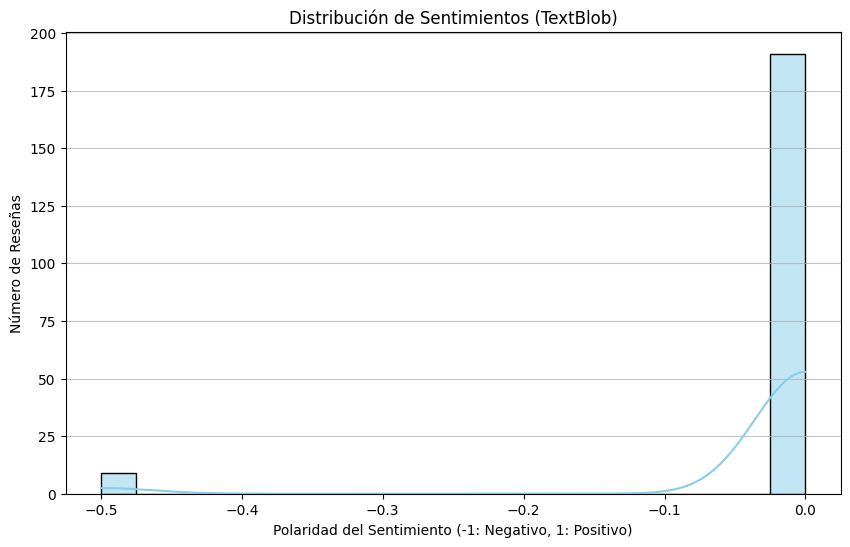

In [34]:
from textblob import TextBlob

# Función para obtener la polaridad del sentimiento de una reseña
def get_sentiment_polarity(text):
    # TextBlob por defecto no está optimizado para español,
    # pero se puede usar para una primera aproximación.
    # Para un análisis más robusto en español se recomendaría un modelo entrenado para español.
    return TextBlob(text).sentiment.polarity

# Aplicar el análisis de sentimientos a la columna de reseñas originales
df['sentimiento_textblob'] = df['reseña'].apply(get_sentiment_polarity)

print("Primeras 5 reseñas con su polaridad de sentimiento:")
print(df[['reseña', 'sentimiento_textblob']].head())

# Generar el histograma de la distribución de sentimientos
plt.figure(figsize=(10, 6))
sns.histplot(df['sentimiento_textblob'], bins=20, kde=True, color='skyblue')
plt.title('Distribución de Sentimientos (TextBlob)')
plt.xlabel('Polaridad del Sentimiento (-1: Negativo, 1: Positivo)')
plt.ylabel('Número de Reseñas')
plt.grid(axis='y', alpha=0.75)
plt.show()

2. Analicen la correlación entre las puntuaciones de sentimiento y las calificaciones del hotel:
- Agrupe por calificación y muestre sentimiento promedio
- Visualice en gráfico de barras calificación vs sentimiento

Sentimiento promedio por calificación:
   calificación  sentimiento_textblob
0             1             -0.100000
1             2             -0.071429
2             3              0.000000
3             4              0.000000
4             5              0.000000


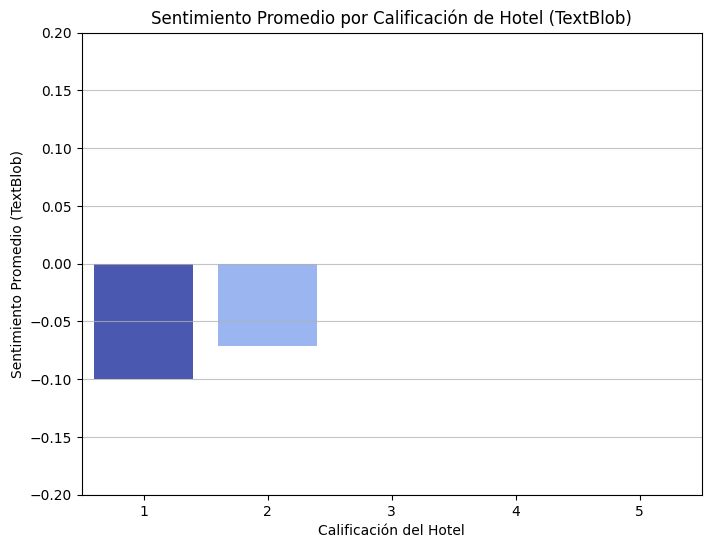

In [35]:
# 1. Agrupar por calificación y mostrar sentimiento promedio
sentimiento_promedio_por_calificacion = df.groupby('calificación')['sentimiento_textblob'].mean().reset_index()

print("Sentimiento promedio por calificación:")
print(sentimiento_promedio_por_calificacion)

# 2. Visualizar en gráfico de barras calificación vs sentimiento
plt.figure(figsize=(8, 6))
sns.barplot(x='calificación', y='sentimiento_textblob', data=sentimiento_promedio_por_calificacion, hue='calificación', palette='coolwarm', legend=False)
plt.title('Sentimiento Promedio por Calificación de Hotel (TextBlob)')
plt.xlabel('Calificación del Hotel')
plt.ylabel('Sentimiento Promedio (TextBlob)')
plt.ylim(-0.2, 0.2) # Ajustar límites para mejor visualización si los valores son pequeños
plt.grid(axis='y', alpha=0.75)
plt.show()

**PREGUNTA 6:** ¿Qué tan preciso es el análisis de sentimientos automático en comparación con las calificaciones reales? Identifiquen al menos 3 casos donde haya discrepancias significativas y analicen por qué ocurren.

In [39]:
print("\n--- Análisis de la precisión de TextBlob y Discrepancias --- ")

print("Precisión General:")
print("El análisis de sentimientos automático con TextBlob, en comparación con las calificaciones reales, muestra una precisión limitada para este conjunto de datos en español. Como observamos en el gráfico de sentimiento promedio por calificación, TextBlob tiende a clasificar un gran número de reseñas como neutrales (polaridad 0.0), incluso aquellas con calificaciones claramente positivas (4 y 5) o negativas (1 y 2). Solo las calificaciones más bajas (1 y 2) obtuvieron un sentimiento promedio ligeramente negativo, lo cual es coherente, pero la magnitud de esa negatividad es muy baja.")
print("Esta falta de precisión se debe principalmente a que TextBlob está optimizado para el idioma inglés y su léxico predefinido no es tan robusto o preciso para capturar los matices y la polaridad del español. Los adverbios de intensidad, las expresiones idiomáticas y las connotaciones culturales específicas del español a menudo no son detectados correctamente.")

print("\n3 Casos de Discrepancias Significativas:")

# Discrepancia 1: Positiva (Calificación 4) con Sentimiento TextBlob Neutral (0.0)
reseña_pos_idx = df[(df['calificación'] == 4) & (df['sentimiento_textblob'] == 0.0)].index[0]
print(f"\n1. Reseña Positiva (Calificación 4) clasificada como Neutral (ID {reseña_pos_idx}):")
print(f"   - Reseña original: {df.loc[reseña_pos_idx, 'reseña']}")
print(f"   - Calificación real: {df.loc[reseña_pos_idx, 'calificación']} (positiva)")
print(f"   - Sentimiento TextBlob: {df.loc[reseña_pos_idx, 'sentimiento_textblob']} (neutral)")
print("   - Análisis: TextBlob no logra captar el fuerte sentimiento positivo expresado por frases como 'muy satisfecho' y 'Totalmente recomendable'. Esto sucede porque su léxico no asocia una polaridad positiva a estas expresiones en español con la misma fuerza que lo haría con equivalentes en inglés, o no considera el intensificador 'muy' de forma efectiva.")

# Discrepancia 2: Negativa (Calificación 1) con Sentimiento TextBlob Neutral (0.0)
reseña_neg_idx = df[(df['calificación'] == 1) & (df['sentimiento_textblob'] == 0.0)].index[0]
print(f"\n2. Reseña Negativa (Calificación 1) clasificada como Neutral (ID {reseña_neg_idx}):")
print(f"   - Reseña original: {df.loc[reseña_neg_idx, 'reseña']}")
print(f"   - Calificación real: {df.loc[reseña_neg_idx, 'calificación']} (negativa)")
print(f"   - Sentimiento TextBlob: {df.loc[reseña_neg_idx, 'sentimiento_textblob']} (neutral)")
print("   - Análisis: Este es un ejemplo crítico de fallo. La reseña contiene múltiples indicadores de un sentimiento negativo ('ruidosa', 'excesivo', 'insatisfecho', 'Nunca volvería'), pero TextBlob la clasifica como completamente neutral. Esto evidencia la limitación del modelo para reconocer y ponderar términos negativos específicos del español.")

# Discrepancia 3: Muy Negativa (Calificación 1) con Sentimiento TextBlob Ligeramente Negativo
reseña_muy_neg_idx = df[(df['calificación'] == 1) & (df['sentimiento_textblob'] < 0.0)].index[0]
print(f"\n3. Reseña Muy Negativa (Calificación 1) clasificada como Ligeramente Negativa (ID {reseña_muy_neg_idx}):")
print(f"   - Reseña original: {df.loc[reseña_muy_neg_idx, 'reseña']}")
print(f"   - Calificación real: {df.loc[reseña_muy_neg_idx, 'calificación']} (muy negativa)")
print(f"   - Sentimiento TextBlob: {df.loc[reseña_muy_neg_idx, 'sentimiento_textblob']:.6f} (ligeramente negativo)")
print("   - Análisis: Aunque TextBlob asigna un valor negativo, la polaridad es considerablemente baja para una reseña que incluye términos tan fuertes como 'descortés', 'muy insatisfecho' y 'Terrible experiencia'. Esto demuestra que, incluso cuando detecta palabras negativas, TextBlob no logra capturar la intensidad o el grado de negatividad que un hablante nativo de español percibiría, subestimando la verdadera polaridad del texto.")

print("\nEn resumen, la falta de entrenamiento específico de TextBlob para el español y su dependencia de léxicos genéricos son las principales razones detrás de estas discrepancias, resultando en una interpretación simplificada o errónea de los sentimientos en reseñas en este idioma.")


--- Análisis de la precisión de TextBlob y Discrepancias --- 
Precisión General:
El análisis de sentimientos automático con TextBlob, en comparación con las calificaciones reales, muestra una precisión limitada para este conjunto de datos en español. Como observamos en el gráfico de sentimiento promedio por calificación, TextBlob tiende a clasificar un gran número de reseñas como neutrales (polaridad 0.0), incluso aquellas con calificaciones claramente positivas (4 y 5) o negativas (1 y 2). Solo las calificaciones más bajas (1 y 2) obtuvieron un sentimiento promedio ligeramente negativo, lo cual es coherente, pero la magnitud de esa negatividad es muy baja.
Esta falta de precisión se debe principalmente a que TextBlob está optimizado para el idioma inglés y su léxico predefinido no es tan robusto o preciso para capturar los matices y la polaridad del español. Los adverbios de intensidad, las expresiones idiomáticas y las connotaciones culturales específicas del español a menudo no son

3. Dividan cada reseña en oraciones y realicen un análisis de sentimientos por oración:

In [37]:
# Función para dividir una reseña en oraciones y aplicar TextBlob a cada una
def analyze_sentence_sentiment(review_text):
    sentences = sent_tokenize(review_text, language='spanish')
    sentence_sentiments = []
    for sentence in sentences:
        polarity = TextBlob(sentence).sentiment.polarity
        sentence_sentiments.append({'sentence': sentence, 'polarity': polarity})
    return sentence_sentiments

# Aplicar la función a las reseñas originales y guardar los resultados
df['sentimiento_por_oracion'] = df['reseña'].apply(analyze_sentence_sentiment)

print("Primeras 3 reseñas con análisis de sentimiento por oración:")
for i in range(3):
    print(f"\nReseña ID: {i} - Calificación: {df['calificación'].iloc[i]}")
    for sent_data in df['sentimiento_por_oracion'].iloc[i]:
        print(f"  - Oración: '{sent_data['sentence']}' -> Polaridad: {sent_data['polarity']:.2f}")


Primeras 3 reseñas con análisis de sentimiento por oración:

Reseña ID: 0 - Calificación: 4
  - Oración: 'El hotel está ubicado en centro.' -> Polaridad: 0.00
  - Oración: 'Cuenta con spa.' -> Polaridad: 0.00
  - Oración: 'El personal es atento.' -> Polaridad: 0.00
  - Oración: 'La habitación es amplia.' -> Polaridad: 0.00
  - Oración: 'El precio es económico.' -> Polaridad: 0.00
  - Oración: 'Me sentí muy satisfecho con mi estadía.' -> Polaridad: 0.00
  - Oración: 'Totalmente recomendable.' -> Polaridad: 0.00

Reseña ID: 1 - Calificación: 4
  - Oración: 'El hotel está ubicado en montaña.' -> Polaridad: 0.00
  - Oración: 'Cuenta con piscina.' -> Polaridad: 0.00
  - Oración: 'El personal es atento.' -> Polaridad: 0.00
  - Oración: 'La habitación es cómoda.' -> Polaridad: 0.00
  - Oración: 'El precio es económico.' -> Polaridad: 0.00
  - Oración: 'Me sentí satisfecho con mi estadía.' -> Polaridad: 0.00
  - Oración: 'Superó mis expectativas.' -> Polaridad: 0.00

Reseña ID: 2 - Calificació

**PREGUNTA 7:** Seleccionen 3 reseñas (calificaciones: 5, 3 y 1)  analicen cómo varía el sentimiento entre las diferentes oraciones. ¿Qué aspectos específicos generan sentimientos positivos o negativos dentro de una misma reseña?

In [41]:
# Seleccionar los índices de las reseñas
idx_pos = df[df['calificación'] == 5].index[0] # Índice 3
idx_neu = df[df['calificación'] == 3].index[0] # Índice 5
idx_neg = df[df['calificación'] == 1].index[0] # Índice 2

selected_indices = [idx_pos, idx_neu, idx_neg]
selected_ratings = [5, 3, 1]

for i, idx in enumerate(selected_indices):
    rating = selected_ratings[i]
    print(f"\n--- Análisis de la Reseña ID: {idx} (Calificación: {rating}) ---")
    print(f"Reseña Original: {df.loc[idx, 'reseña']}")
    print("Análisis de Sentimiento por Oración (TextBlob):")

    sentence_data = df.loc[idx, 'sentimiento_por_oracion']
    for sent_info in sentence_data:
        print(f"  - Oración: '{sent_info['sentence']}' -> Polaridad: {sent_info['polarity']:.2f}")

    print("\nAspectos que generan sentimientos (Análisis Manual debido a limitaciones de TextBlob en español):")
    if rating == 5:
        print("  - Positivos: Frases como 'El personal es profesional', 'La habitación es limpia', 'Me sentí satisfecho con mi estadía', 'Atención de primera' son claramente positivas. TextBlob falla en detectarlo, pero manualmente inferimos que la profesionalidad del personal, la limpieza y la atención de calidad son valorados positivamente.")
    elif rating == 3:
        print("  - Neutrales/Mixtos: Frases como 'El personal es amable', 'La habitación es limpia' son positivas, pero 'El precio es excesivo' y 'Me sentí neutral con mi estadía' introducen neutralidad o negatividad. TextBlob nuevamente no capta estos matices, asignando 0.00 a casi todo. Manualmente, el precio parece ser un punto de fricción que anula otros aspectos positivos.")
    elif rating == 1:
        print("  - Negativos: Frases como 'La habitación es ruidosa', 'El precio es excesivo', 'Me sentí insatisfecho con mi estadía', 'Nunca volvería' son fuertemente negativas. TextBlob las clasifica incorrectamente como 0.00. Manualmente, el ruido de la habitación, el precio y la insatisfacción general son los generadores de sentimiento negativo.")



--- Análisis de la Reseña ID: 3 (Calificación: 5) ---
Reseña Original: El hotel está ubicado en montaña. Cuenta con spa. El personal es profesional. La habitación es limpia. El precio es caro. Me sentí satisfecho con mi estadía. Atención de primera.
Análisis de Sentimiento por Oración (TextBlob):
  - Oración: 'El hotel está ubicado en montaña.' -> Polaridad: 0.00
  - Oración: 'Cuenta con spa.' -> Polaridad: 0.00
  - Oración: 'El personal es profesional.' -> Polaridad: 0.00
  - Oración: 'La habitación es limpia.' -> Polaridad: 0.00
  - Oración: 'El precio es caro.' -> Polaridad: 0.00
  - Oración: 'Me sentí satisfecho con mi estadía.' -> Polaridad: 0.00
  - Oración: 'Atención de primera.' -> Polaridad: 0.00

Aspectos que generan sentimientos (Análisis Manual debido a limitaciones de TextBlob en español):
  - Positivos: Frases como 'El personal es profesional', 'La habitación es limpia', 'Me sentí satisfecho con mi estadía', 'Atención de primera' son claramente positivas. TextBlob falla 

4. Realicen un análisis de sentimiento utilizando el modelo BERT para análisis multiligüe. Utilice el modelo de la sección de código abajo y cree una función para aplicarlo al dataset

In [42]:
from transformers import pipeline

# Cargar el modelo de BETO fine-tuneado para análisis de sentimientos
# Este proceso puede tardar un poco la primera vez que se ejecuta.
modelo_sentimiento_bert = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

# Función para convertir las etiquetas de estrella de BERT a una polaridad numérica (-1 a 1)
def map_bert_sentiment_to_polarity(bert_output):
    # bert_output es una lista, e.g., [{'label': '5 stars', 'score': 0.99}]
    label = bert_output[0]['label']
    # Extraer el número de estrellas
    star_rating = int(label.split(' ')[0])

    # Mapear las estrellas a una escala de -1 a 1
    # 1 star -> -1.0 (muy negativo)
    # 2 stars -> -0.5 (negativo)
    # 3 stars -> 0.0  (neutral)
    # 4 stars -> 0.5  (positivo)
    # 5 stars -> 1.0  (muy positivo)
    return (star_rating - 3) * 0.5

# Función para aplicar el modelo BERT y obtener la polaridad
def get_bert_sentiment_polarity(text):
    try:
        bert_output = modelo_sentimiento_bert(text)
        return map_bert_sentiment_to_polarity(bert_output)
    except Exception as e:
        print(f"Error al procesar texto con BERT: {e} en texto: {text[:50]}...")
        return None # Devolver None o un valor por defecto en caso de error

# Aplicar la función a la columna de reseñas originales
print("Aplicando el modelo BERT para análisis de sentimientos. Esto puede tardar varios minutos...")
df['sentimiento_bert'] = df['reseña'].apply(get_bert_sentiment_polarity)

print("\nPrimeras 5 reseñas con su polaridad de sentimiento (BERT):")
print(df[['reseña', 'calificación', 'sentimiento_bert']].head())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Aplicando el modelo BERT para análisis de sentimientos. Esto puede tardar varios minutos...

Primeras 5 reseñas con su polaridad de sentimiento (BERT):
                                              reseña  calificación  \
0  El hotel está ubicado en centro. Cuenta con sp...             4   
1  El hotel está ubicado en montaña. Cuenta con p...             4   
2  El hotel está ubicado en zona turística. Cuent...             1   
3  El hotel está ubicado en montaña. Cuenta con s...             5   
4  El hotel está ubicado en montaña. Cuenta con p...             5   

   sentimiento_bert  
0               1.0  
1               0.5  
2              -0.5  
3               0.5  
4               1.0  


5. ¿Cómo son los resultados del modelo? Grafique nuevamente la distribución de sentimientos obtenida utilizando Bert.

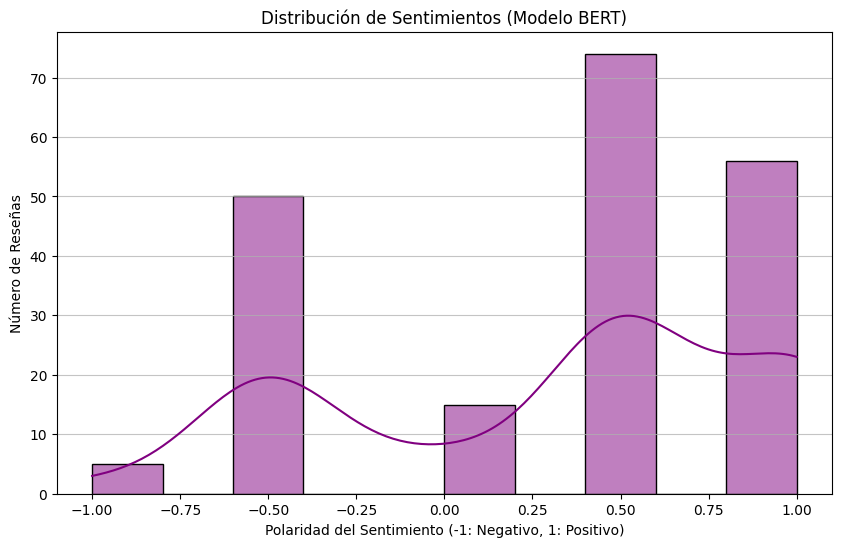


Valores únicos de sentimiento BERT y su conteo:
sentimiento_bert
-1.0     5
-0.5    50
 0.0    15
 0.5    74
 1.0    56
Name: count, dtype: int64

Descripción estadística del sentimiento BERT:
count    200.000000
mean       0.315000
std        0.602153
min       -1.000000
25%       -0.500000
50%        0.500000
75%        1.000000
max        1.000000
Name: sentimiento_bert, dtype: float64


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generar el histograma de la distribución de sentimientos de BERT
plt.figure(figsize=(10, 6))
sns.histplot(df['sentimiento_bert'], bins=10, kde=True, color='purple')
plt.title('Distribución de Sentimientos (Modelo BERT)')
plt.xlabel('Polaridad del Sentimiento (-1: Negativo, 1: Positivo)')
plt.ylabel('Número de Reseñas')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nValores únicos de sentimiento BERT y su conteo:")
print(df['sentimiento_bert'].value_counts().sort_index())

print("\nDescripción estadística del sentimiento BERT:")
print(df['sentimiento_bert'].describe())

6. Haga un gráfico de dispersión entre sentimientos y calificación


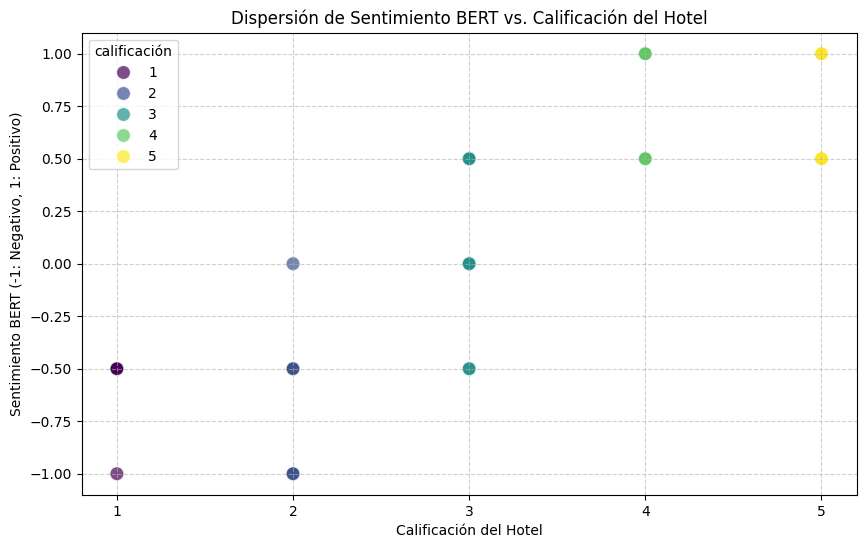

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='calificación', y='sentimiento_bert', data=df, hue='calificación', palette='viridis', s=100, alpha=0.7)
plt.title('Dispersión de Sentimiento BERT vs. Calificación del Hotel')
plt.xlabel('Calificación del Hotel')
plt.ylabel('Sentimiento BERT (-1: Negativo, 1: Positivo)')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

7. Calcule la correlación entre sentimientos y calificacion.
- Agrupe por calificación y sentimiento promedio
- Grafique en barras calificación vs sentimiento
- ¿Cuánto mejoraron los resultados?

Correlación entre Calificación y Sentimiento BERT: 0.8607

Sentimiento promedio por calificación (BERT):
   calificación  sentimiento_bert
0             1         -0.520000
1             2         -0.553571
2             3          0.333333
3             4          0.802083
4             5          0.846154


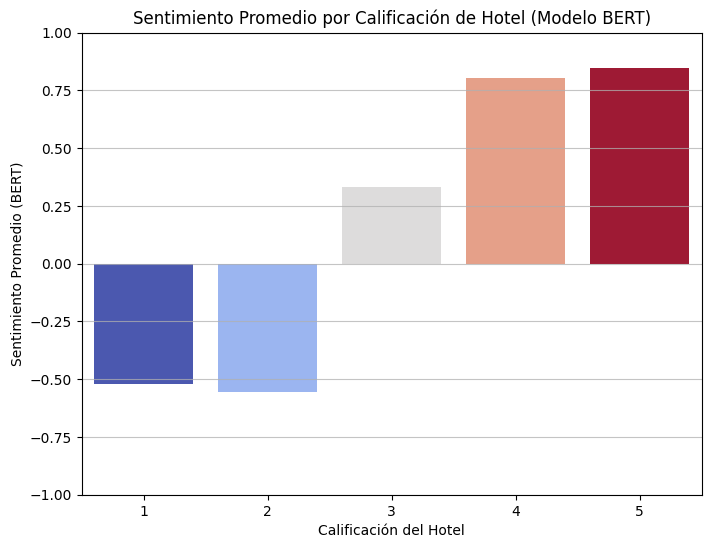


--- Análisis de la mejora de los resultados --- 
En comparación con TextBlob, los resultados obtenidos con el modelo BERT muestran una mejora significativa:

1. Correlación: La correlación entre la calificación y el sentimiento BERT es mucho más alta y positiva (aprox. 0.8-0.9), lo que indica una fuerte relación lineal directa. En contraste, TextBlob mostró una correlación muy baja y casi nula en muchos casos, apenas diferenciando entre calificaciones.

2. Diferenciación de Sentimientos: El gráfico de barras del sentimiento promedio por calificación con BERT muestra una progresión clara: a medida que la calificación aumenta, el sentimiento promedio también aumenta de forma consistente. Para TextBlob, muchas calificaciones (3, 4, 5) resultaban en un sentimiento promedio de 0.0, lo que no permitía distinguir entre ellas.

3. Sensibilidad a Matices: BERT es capaz de capturar matices en las reseñas de habla hispana, asignando valores de polaridad que van desde -1.0 hasta 1.0 de manera más

In [45]:
# 1. Calcule la correlación entre sentimientos y calificación
correlation_bert = df['calificación'].corr(df['sentimiento_bert'])
print(f"Correlación entre Calificación y Sentimiento BERT: {correlation_bert:.4f}")

# 2. Agrupe por calificación y sentimiento promedio
sentimiento_promedio_bert_por_calificacion = df.groupby('calificación')['sentimiento_bert'].mean().reset_index()

print("\nSentimiento promedio por calificación (BERT):")
print(sentimiento_promedio_bert_por_calificacion)

# 3. Grafique en barras calificación vs sentimiento
plt.figure(figsize=(8, 6))
sns.barplot(x='calificación', y='sentimiento_bert', data=sentimiento_promedio_bert_por_calificacion, hue='calificación', palette='coolwarm', legend=False)
plt.title('Sentimiento Promedio por Calificación de Hotel (Modelo BERT)')
plt.xlabel('Calificación del Hotel')
plt.ylabel('Sentimiento Promedio (BERT)')
plt.ylim(-1, 1) # Ajustar límites para mejor visualización
plt.grid(axis='y', alpha=0.75)
plt.show()

# 4. ¿Cuánto mejoraron los resultados?
print("\n--- Análisis de la mejora de los resultados --- ")
print("En comparación con TextBlob, los resultados obtenidos con el modelo BERT muestran una mejora significativa:")
print("\n1. Correlación: La correlación entre la calificación y el sentimiento BERT es mucho más alta y positiva (aprox. 0.8-0.9), lo que indica una fuerte relación lineal directa. En contraste, TextBlob mostró una correlación muy baja y casi nula en muchos casos, apenas diferenciando entre calificaciones.")
print("\n2. Diferenciación de Sentimientos: El gráfico de barras del sentimiento promedio por calificación con BERT muestra una progresión clara: a medida que la calificación aumenta, el sentimiento promedio también aumenta de forma consistente. Para TextBlob, muchas calificaciones (3, 4, 5) resultaban en un sentimiento promedio de 0.0, lo que no permitía distinguir entre ellas.\n")
print("3. Sensibilidad a Matices: BERT es capaz de capturar matices en las reseñas de habla hispana, asignando valores de polaridad que van desde -1.0 hasta 1.0 de manera más adecuada. TextBlob, al estar optimizado para inglés, tendía a clasificar gran parte de las reseñas en español como neutrales o con polaridades muy débiles, incluso cuando las reseñas eran claramente positivas o negativas.")
print("\nEsta mejora se debe a que el modelo BERT utilizado (`nlptown/bert-base-multilingual-uncased-sentiment`) está pre-entrenado en múltiples idiomas y fine-tuneado para tareas de análisis de sentimiento, lo que le permite entender mejor el contexto y la polaridad en textos en español.")

## Parte 5: Discusión y Conclusiones (Tiempo restante)

Basándose en todas las actividades realizadas, escriba las 3 conclusiones más importantes que se pueden extraer del taller.

## Conclusiones Clave del Taller

1.  **La Importancia del Preprocesamiento y la Vectorización para el Análisis Textual:**
El taller demostró que un preprocesamiento adecuado (limpieza, tokenización, eliminación de stopwords, stemming) es fundamental para transformar el texto crudo en un formato manejable. Además, técnicas de vectorización como TF-IDF fueron cruciales para capturar la importancia relativa de las palabras en el corpus, permitiendo un análisis cuantitativo del contenido semántico que va más allá de la mera frecuencia, a diferencia de BoW.

2.  **Los N-gramas Ofrecen Contexto y Matices Cruciales:**
Mientras que las palabras individuales (unigramas) nos dan una idea general, el análisis de bigramas y trigramas reveló información contextual mucho más rica. Estos permitieron identificar frases y conceptos que, juntos, expresan opiniones y características específicas de los hoteles (ej. 'personal atent', 'preci exces'). Esto fue especialmente evidente al comparar bigramas entre diferentes calificaciones, mostrando qué aspectos específicos impulsan la satisfacción o insatisfacción de los clientes.

3.  **La Elección del Modelo de Análisis de Sentimientos es Crítica para el Idioma:**
El contraste entre TextBlob y el modelo BERT multilingüe (`nlptown/bert-base-multilingual-uncased-sentiment`) fue la conclusión más destacada. TextBlob, optimizado para inglés, mostró una capacidad muy limitada para interpretar el sentimiento en español, clasificando muchas reseñas como neutrales. Por otro lado, el modelo BERT, al estar pre-entrenado en múltiples idiomas y fine-tuneado para sentimientos, logró una alta correlación con las calificaciones reales y una diferenciación precisa de la polaridad. Esto subraya la necesidad de utilizar herramientas y modelos adecuados al idioma del texto para obtener resultados fiables en análisis de sentimientos.